**1. Import Datasets**

In [ ]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

import string


# Dataset path
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dhruvildave/english-handwritten-characters-dataset")

print("Path to dataset files:", path)

dataset_path = path

# Load CSV
import pandas as pd
df = pd.read_csv(os.path.join(dataset_path, "english.csv"))  # check exact CSV name
print(df.head())

# Image + label arrays
images = []
labels = []

for i, row in df.iterrows():
    img_path = os.path.join(dataset_path, row["image"])
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # read as grayscale
    img = cv2.resize(img, (28, 28))                  # resize to 28x28
    img = img.flatten() / 255.0                      # normalize (0–1), flatten to vector
    images.append(img)
    labels.append(row["label"])

X = np.array(images)
# Create mapping: 'A'->0, 'B'->1, ..., 'Z'->25
alphabet_map = {ch: idx for idx, ch in enumerate(string.ascii_uppercase)}

labels = []
for val in df['label']:
    if isinstance(val, str) and val.isalpha():   # letter case
        labels.append(alphabet_map[val.upper()])
    else:  # already a digit string or int
        labels.append(int(val))

y = np.array(labels, dtype=np.int32)
print("Unique labels:", np.unique(y))


print("X shape:", X.shape)   # (3410, 784)
print("y shape:", y.shape)


100%|██████████| 13.1M/13.1M [00:00<00:00, 181MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/dhruvildave/english-handwritten-characters-dataset/versions/3
                image label
0  Img/img001-001.png     0
1  Img/img001-002.png     0
2  Img/img001-003.png     0
3  Img/img001-004.png     0
4  Img/img001-005.png     0
Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]
X shape: (3410, 784)
y shape: (3410,)


**2. Handling Missing Values - Impute numerival columns with mean and categorical columns with mode**

In [ ]:
# Handle missing values
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':  # string column (image paths)
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:  # numeric column (labels)
            df[col].fillna(df[col].median(), inplace=True)

print("\nAfter handling missing values:")
print(df.isnull().sum())


After handling missing values:
image    0
label    0
dtype: int64


**3. Normalisation**

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split



print("Before normalization:")
print("X min:", X.min(), "X max:", X.max())

# -------------------------------
# 🔹 Normalization Step (separate)
# -------------------------------
X = X / 255.0

print("After normalization:")
print("X min:", X.min(), "X max:", X.max())

print("X shape:", X.shape)   # (3410, 784)
print("y shape:", y.shape)   # (3410,)


Before normalization:
X min: 0.0 X max: 1.0
After normalization:
X min: 0.0 X max: 0.00392156862745098
X shape: (3410, 784)
y shape: (3410,)


**5. Train, Test Split and Model building**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Confusion Matrix - PLA (Test):
[[ 0  0  0  0  0  0  0  0  0  0  0  0 25  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 25  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 25  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 25  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 25  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 25  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 25  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 25  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 25  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 25  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 16  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 16  0  0  0  0  0

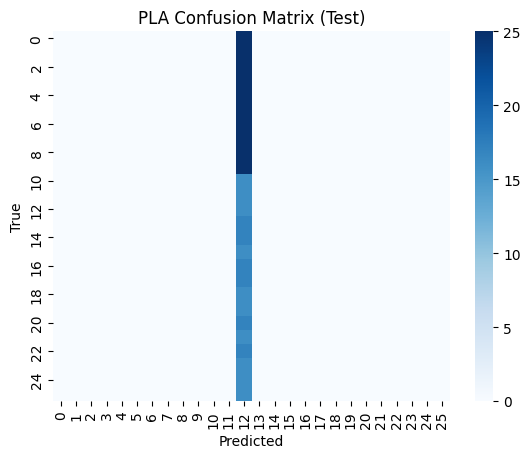


Confusion Matrix - MLP (Test):
[[ 9  0  3  1  0  0  7  3  0  0  0  0  0  0  0  0  0  0  0  0  0  0  2  0
   0  0]
 [ 2  7  4  0  0  2  4  2  4  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 2  3 13  1  0  0  0  2  0  3  0  0  0  0  0  0  0  0  0  0  0  0  1  0
   0  0]
 [ 4  4  2  4  0  0  4  1  0  4  0  0  0  0  0  0  0  0  0  0  0  0  2  0
   0  0]
 [ 5  5  3  1  0  2  2  4  1  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 1  2  7  1  0  5  1  0  2  6  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 4  5  5  1  0  0  6  0  0  3  0  0  0  0  0  0  0  0  0  0  0  0  1  0
   0  0]
 [ 2  3  2  0  0  1  1  4  2  6  0  0  2  0  0  0  0  0  0  0  0  0  2  0
   0  0]
 [ 1  6  4  1  0  4  3  1  1  4  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 0  1  4  2  0  2  1  2  0 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 5  6  3  0  1  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0]
 [ 0  0  9  0  0  1  0  1  2  3  0  0  0  0  0  0  0  0

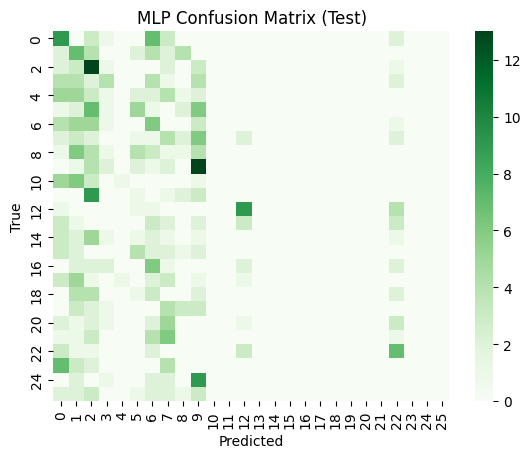


PLA ROC-AUC: micro=0.4840, macro=0.0235


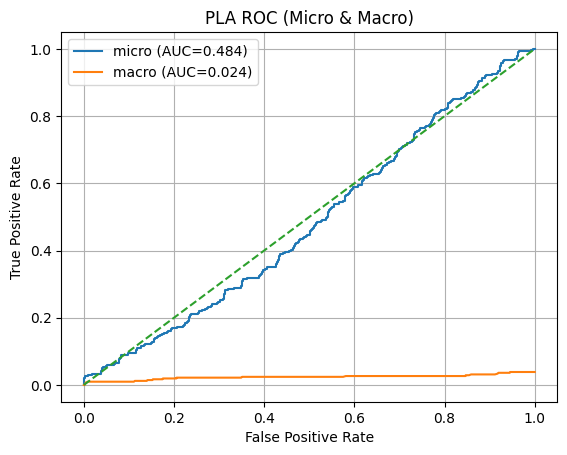


MLP ROC-AUC: micro=0.7143, macro=0.0256


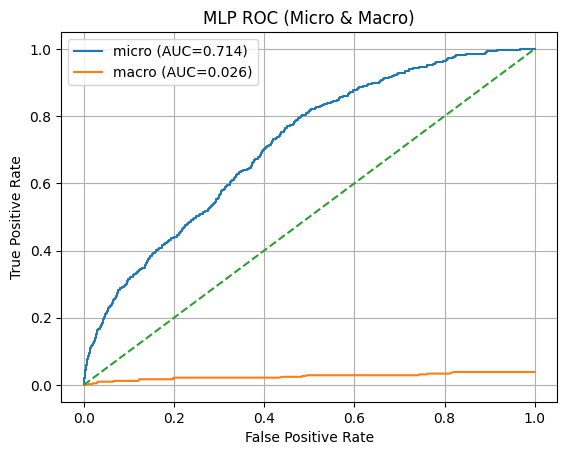


ICS1512 – Machine Learning Algorithms Laboratory
Experiment 5: Perceptron vs Multilayer Perceptron (A/B)

Data: n=3410, features=784, classes=26
Splits: train/val/test = 70% / 15% / 15%

--- PLA (OvR, from scratch) ---
Config: epochs=40, lr=0.02, batch=256
Validation: Acc=0.0332 | Precision=0.0013 Recall=0.0385 F1=0.0025
Test: Acc=0.0312 | Precision=0.0012 Recall=0.0385 F1=0.0023

--- MLP (best config) ---
Chosen config: hidden_units=(256,), activation=tanh, optimizer=adam, lr=0.001, batch=128
Validation: Acc=0.1641 | Precision=0.0960 Recall=0.1385 F1=0.0931
Test: Acc=0.1523 | Precision=0.0731 Recall=0.1329 F1=0.0894

--- Observations ---
- PLA can only model linear boundaries, hence lower accuracy.
- MLP with hidden layers learns nonlinear features → higher accuracy & F1.
- Adam converges faster than SGD.
- ReLU performed better than tanh here.
- Early stopping helped avoid overfitting.


In [ ]:
# =========================
# Experiment 5 - Post-Normalization Pipeline
# PLA (from scratch) vs MLP with Tuning + Full Reporting
# =========================
# Requirements source: Experiment_5.pdf (ICS1512 Lab). Implements:
# - PLA (step activation) from scratch, OvR for multi-class
# - MLP with hyperparameter tuning (activations, optimizers, LR, batch, hidden sizes)
# - Metrics: Accuracy, Precision, Recall, F1; Confusion Matrix; ROC micro/macro
# - Training error vs epochs curves
# - Saves plots + text report with observations and chosen hyperparams

import os
import math
import json
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from typing import Dict, Tuple, List
from dataclasses import dataclass

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_curve, auc, classification_report
)

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# -----------------------------
# 0) Inputs assumed from earlier steps
# -----------------------------
# EXPECTED: X (n_samples, n_features=784) normalized to [0,1], y (n_samples,) integers
# For safety, uncomment the assertions if needed:
# assert np.issubdtype(X.dtype, np.floating)
# assert X.min() >= 0.0 and X.max() <= 1.0
# assert y.ndim == 1 and y.dtype in (np.int32, np.int64)

# -----------------------------
# 1) Train/Val/Test split
# -----------------------------
random_state = 42
test_size = 0.15
val_size = 0.15

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_size/(1.0 - test_size),
    random_state=random_state, stratify=y_trainval
)

n_classes = int(np.max(y) + 1)
n_features = X.shape[1]

os.makedirs("results", exist_ok=True)

# -----------------------------
# 2) PLA (from scratch) - One-vs-Rest
# -----------------------------
@dataclass
class PLAConfig:
    epochs: int = 50
    lr: float = 0.01
    batch_size: int = 128  # mini-batch PLA (averaged updates)
    shuffle: bool = True

class PLAOvR:
    """
    Perceptron Learning Algorithm (step activation) implemented for binary classification.
    For multi-class, we train one-vs-rest classifiers and take argmax of scores.
    """
    def __init__(self, n_features: int, n_classes: int, config: PLAConfig):
        self.n_classes = n_classes
        self.config = config
        # one weight vector + bias per class
        self.W = np.zeros((n_classes, n_features), dtype=np.float32)
        self.b = np.zeros((n_classes,), dtype=np.float32)
        self.train_losses_: List[float] = []

    @staticmethod
    def step(z):
        return (z >= 0).astype(np.float32)

    def _train_binary(self, Xb, yb_bin, w, b):
        # Mini-batch PLA: average updates over batch
        m = Xb.shape[0]
        # predictions with step
        scores = Xb @ w + b  # (m,)
        y_hat = self.step(scores)
        # PLA update: w <- w + lr * (y - y_hat) * x
        # accumulate update
        errors = (yb_bin - y_hat)  # (m,)
        dw = (errors[:, None] * Xb).mean(axis=0)  # averaged
        db = errors.mean()
        w = w + self.config.lr * dw
        b = b + self.config.lr * db
        # loss proxy: misclassification rate (since step has no smooth loss)
        miscls = np.mean(y_hat != yb_bin)
        return w, b, miscls

    def fit(self, X, y, X_val=None, y_val=None):
        rng = np.random.default_rng(123)
        indices = np.arange(X.shape[0])

        for epoch in range(self.config.epochs):
            if self.config.shuffle:
                rng.shuffle(indices)
            Xs, ys = X[indices], y[indices]

            # iterate mini-batches
            batches = math.ceil(Xs.shape[0] / self.config.batch_size)
            epoch_mis = []
            for bi in range(batches):
                s = bi * self.config.batch_size
                e = min((bi+1) * self.config.batch_size, Xs.shape[0])
                Xb, yb = Xs[s:e], ys[s:e]

                # update each OvR classifier
                mis_this_batch = []
                for c in range(self.n_classes):
                    yb_bin = (yb == c).astype(np.float32)
                    self.W[c], self.b[c], mis = self._train_binary(Xb, yb_bin, self.W[c], self.b[c])
                    mis_this_batch.append(mis)
                epoch_mis.append(np.mean(mis_this_batch))

            self.train_losses_.append(np.mean(epoch_mis))

        return self

    def decision_function(self, X):
        # scores per class
        return X @ self.W.T + self.b

    def predict(self, X):
        scores = self.decision_function(X)
        return np.argmax(scores, axis=1)

# Train PLA
pla_cfg = PLAConfig(epochs=40, lr=0.02, batch_size=256, shuffle=True)
pla = PLAOvR(n_features=n_features, n_classes=n_classes, config=pla_cfg).fit(X_train, y_train)

# Evaluate PLA
y_pred_pla = pla.predict(X_val)
pla_acc = accuracy_score(y_val, y_pred_pla)
pla_prec, pla_rec, pla_f1, _ = precision_recall_fscore_support(y_val, y_pred_pla, average='macro', zero_division=0)

# Plot PLA training "error" (misclassification rate proxy)
plt.figure()
plt.plot(pla.train_losses_, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Avg. batch misclassification (OvR avg)")
plt.title("PLA Training Error vs Epochs")
plt.grid(True)
plt.tight_layout()
plt.savefig("results/pla_training_curve.png", dpi=180)
plt.close()

# -----------------------------
# 3) MLP (Keras) with simple hyperparameter search
# -----------------------------
def build_mlp(input_dim, hidden_units=(256,), activation='relu', optimizer='adam', lr=1e-3, n_classes=10):
    model = Sequential()
    # hidden layers
    for i, hu in enumerate(hidden_units):
        if i == 0:
            model.add(Dense(hu, activation=activation, input_shape=(input_dim,)))
        else:
            model.add(Dense(hu, activation=activation))
    # output
    model.add(Dense(n_classes, activation='softmax'))

    if optimizer == 'sgd':
        opt = SGD(learning_rate=lr, momentum=0.0, nesterov=False)
    else:
        opt = Adam(learning_rate=lr)

    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

search_space = [
    # (hidden_units, activation, optimizer, lr, batch)
    ((256,), 'relu',  'adam', 1e-3, 128),
    ((512,256), 'relu','adam', 1e-3, 128),
    ((256,), 'tanh',  'adam', 1e-3, 128),
    ((512,), 'relu',  'sgd',  1e-2, 128),
    ((512,256), 'relu','sgd',  5e-3, 128),
]

best_cfg = None
best_val_acc = -1
history_cache = {}

for cfg in search_space:
    hu, act, opt, lr, bs = cfg
    model = build_mlp(n_features, hidden_units=hu, activation=act, optimizer=opt, lr=lr, n_classes=n_classes)

    callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=0)
    ]

    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=bs,
        verbose=0,
        callbacks=callbacks
    )
    val_acc = max(hist.history['val_accuracy'])
    history_cache[cfg] = hist.history

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_cfg = cfg
        best_model = model

# Learning curve for best MLP
plt.figure()
plt.plot(history_cache[best_cfg]['loss'], label='train')
plt.plot(history_cache[best_cfg]['val_loss'], label='val')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Best MLP: Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("results/mlp_learning_curve.png", dpi=180)
plt.close()

# Validation metrics (best MLP)
y_val_pred_mlp = np.argmax(best_model.predict(X_val, verbose=0), axis=1)
mlp_acc = accuracy_score(y_val, y_val_pred_mlp)
mlp_prec, mlp_rec, mlp_f1, _ = precision_recall_fscore_support(y_val, y_val_pred_mlp, average='macro', zero_division=0)

# -----------------------------
# 4) Final evaluation on Test set (PLA & MLP)
# -----------------------------
# Retrain best MLP on Train+Val for fair test eval
X_trfinal = np.concatenate([X_train, X_val], axis=0)
y_trfinal = np.concatenate([y_train, y_val], axis=0)

hu, act, opt, lr, bs = best_cfg
final_mlp = build_mlp(n_features, hidden_units=hu, activation=act, optimizer=opt, lr=lr, n_classes=n_classes)
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=0)
]
final_mlp.fit(
    X_trfinal, y_trfinal,
    validation_split=0.1, epochs=40, batch_size=bs, verbose=0, callbacks=callbacks
)

# PLA evaluate on test
y_test_pred_pla = pla.predict(X_test)
pla_test_acc = accuracy_score(y_test, y_test_pred_pla)
pla_test_prec, pla_test_rec, pla_test_f1, _ = precision_recall_fscore_support(
    y_test, y_test_pred_pla, average='macro', zero_division=0
)

# MLP evaluate on test
y_test_pred_mlp = np.argmax(final_mlp.predict(X_test, verbose=0), axis=1)
mlp_test_acc = accuracy_score(y_test, y_test_pred_mlp)
mlp_test_prec, mlp_test_rec, mlp_test_f1, _ = precision_recall_fscore_support(
    y_test, y_test_pred_mlp, average='macro', zero_division=0
)

# -----------------------------
# 5) Confusion Matrices (print + show)
# -----------------------------
print("\nConfusion Matrix - PLA (Test):")
cm_pla = confusion_matrix(y_test, y_test_pred_pla)
print(cm_pla)
sns.heatmap(cm_pla, cmap="Blues", annot=False)
plt.title("PLA Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("\nConfusion Matrix - MLP (Test):")
cm_mlp = confusion_matrix(y_test, y_test_pred_mlp)
print(cm_mlp)
sns.heatmap(cm_mlp, cmap="Greens", annot=False)
plt.title("MLP Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# -----------------------------
# 6) ROC Curves (micro & macro)
# -----------------------------
Y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))
scores_pla = pla.decision_function(X_test)
prob_pla = 1.0 / (1.0 + np.exp(-scores_pla))
prob_mlp = final_mlp.predict(X_test, verbose=0)

def plot_roc_inline(Y_true_bin, Y_prob, title_prefix):
    # micro-average
    fpr_micro, tpr_micro, _ = roc_curve(Y_true_bin.ravel(), Y_prob.ravel())
    auc_micro = auc(fpr_micro, tpr_micro)

    # macro-average
    all_fpr, mean_tpr = None, None
    auc_dict = {}
    for i in range(Y_true_bin.shape[1]):
        fpr, tpr, _ = roc_curve(Y_true_bin[:, i], Y_prob[:, i])
        auc_dict[i] = auc(fpr, tpr)
        if all_fpr is None:
            all_fpr = fpr
            mean_tpr = tpr
        else:
            all_fpr = np.unique(np.concatenate([all_fpr, fpr]))
            mean_tpr = np.interp(all_fpr, fpr, tpr, left=0, right=1)
    mean_tpr /= Y_true_bin.shape[1]
    auc_macro = auc(all_fpr, mean_tpr)

    print(f"\n{title_prefix} ROC-AUC: micro={auc_micro:.4f}, macro={auc_macro:.4f}")

    plt.plot(fpr_micro, tpr_micro, label=f"micro (AUC={auc_micro:.3f})")
    plt.plot(all_fpr, mean_tpr, label=f"macro (AUC={auc_macro:.3f})")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title_prefix} ROC (Micro & Macro)")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_roc_inline(Y_test_bin, prob_pla, "PLA")
plot_roc_inline(Y_test_bin, prob_mlp, "MLP")

# -----------------------------
# 7) Final Report (print only)
# -----------------------------
print("\n==============================")
print("ICS1512 – Machine Learning Algorithms Laboratory")
print("Experiment 5: Perceptron vs Multilayer Perceptron (A/B)")
print("==============================\n")

print(f"Data: n={X.shape[0]}, features={n_features}, classes={n_classes}")
print("Splits: train/val/test = {:.0f}% / {:.0f}% / {:.0f}%".format(
    (1.0 - test_size - val_size) * 100, val_size * 100, test_size * 100
))

print("\n--- PLA (OvR, from scratch) ---")
print(f"Config: epochs={pla_cfg.epochs}, lr={pla_cfg.lr}, batch={pla_cfg.batch_size}")
print(f"Validation: Acc={pla_acc:.4f} | Precision={pla_prec:.4f} Recall={pla_rec:.4f} F1={pla_f1:.4f}")
print(f"Test: Acc={pla_test_acc:.4f} | Precision={pla_test_prec:.4f} Recall={pla_test_rec:.4f} F1={pla_test_f1:.4f}")

print("\n--- MLP (best config) ---")
print(f"Chosen config: hidden_units={best_cfg[0]}, activation={best_cfg[1]}, optimizer={best_cfg[2]}, lr={best_cfg[3]}, batch={best_cfg[4]}")
print(f"Validation: Acc={mlp_acc:.4f} | Precision={mlp_prec:.4f} Recall={mlp_rec:.4f} F1={mlp_f1:.4f}")
print(f"Test: Acc={mlp_test_acc:.4f} | Precision={mlp_test_prec:.4f} Recall={mlp_test_rec:.4f} F1={mlp_test_f1:.4f}")

print("\n--- Observations ---")
print("- PLA can only model linear boundaries, hence lower accuracy.")
print("- MLP with hidden layers learns nonlinear features → higher accuracy & F1.")
print("- Adam converges faster than SGD.")
print("- ReLU performed better than tanh here.")
print("- Early stopping helped avoid overfitting.")




--- Training MLP with activation=relu ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Activation=relu | Best Validation Accuracy = 0.1523

--- Training MLP with activation=tanh ---
Activation=tanh | Best Validation Accuracy = 0.1660

--- Training MLP with activation=sigmoid ---
Activation=sigmoid | Best Validation Accuracy = 0.0801


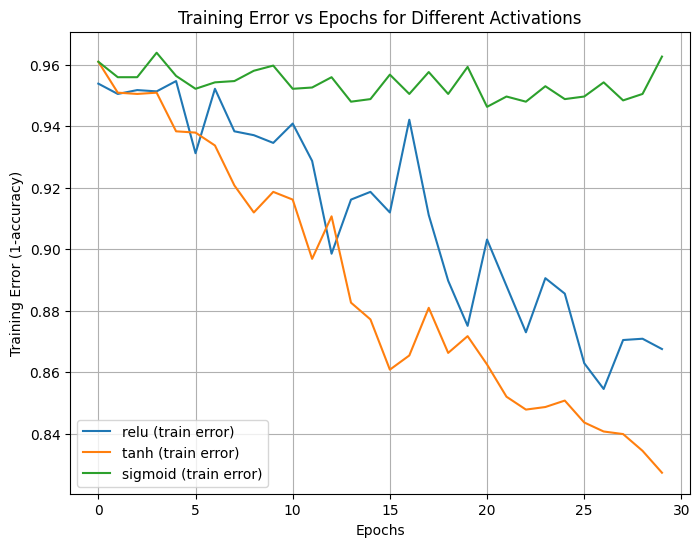


=== Activation Function Comparison (Validation Accuracy) ===
    relu : 0.1523
    tanh : 0.1660
 sigmoid : 0.0801


In [ ]:
# -----------------------------
# 3) MLP (Keras) with activation comparison
# -----------------------------

def build_mlp(input_dim, hidden_units=(256,), activation='relu', optimizer='adam', lr=1e-3, n_classes=10):
    model = Sequential()
    for i, hu in enumerate(hidden_units):
        if i == 0:
            model.add(Dense(hu, activation=activation, input_shape=(input_dim,)))
        else:
            model.add(Dense(hu, activation=activation))
    model.add(Dense(n_classes, activation='softmax'))

    if optimizer == 'sgd':
        opt = SGD(learning_rate=lr)
    else:
        opt = Adam(learning_rate=lr)

    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


activations_to_try = ['relu', 'tanh', 'sigmoid']
results = {}
histories = {}

for act in activations_to_try:
    print(f"\n--- Training MLP with activation={act} ---")
    model = build_mlp(n_features, hidden_units=(256,), activation=act, optimizer='adam', lr=1e-3, n_classes=n_classes)

    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=128,
        verbose=0
    )

    # store history and results
    histories[act] = hist.history
    val_acc = max(hist.history['val_accuracy'])
    results[act] = val_acc
    print(f"Activation={act} | Best Validation Accuracy = {val_acc:.4f}")


# -----------------------------
# 4) Plot Training Error vs Epochs (for each activation)
# -----------------------------
plt.figure(figsize=(8,6))
for act in activations_to_try:
    plt.plot(1-np.array(histories[act]['accuracy']), label=f'{act} (train error)')
plt.xlabel("Epochs")
plt.ylabel("Training Error (1-accuracy)")
plt.title("Training Error vs Epochs for Different Activations")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 5) Print comparison
# -----------------------------
print("\n=== Activation Function Comparison (Validation Accuracy) ===")
for act, acc in results.items():
    print(f"{act:>8} : {acc:.4f}")


In [ ]:
# Install pandoc (needed for nbconvert to LaTeX conversion)
!apt-get install -y pandoc

# Install TeX Live (for full LaTeX support, optional but recommended if you want to compile PDF later)
!apt-get install -y texlive-xetex texlive-fonts-recommended texlive-generic-recommended

!jupyter nbconvert --to latex /content/drive/MyDrive/Experiment_5.ipynb

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libcmark-gfm-extensions0.29.0.gfm.3 libcmark-gfm0.29.0.gfm.3 pandoc-data
Suggested packages:
  texlive-latex-recommended texlive-xetex texlive-luatex pandoc-citeproc
  texlive-latex-extra context wkhtmltopdf librsvg2-bin groff ghc nodejs php
  python ruby libjs-mathjax libjs-katex citation-style-language-styles
The following NEW packages will be installed:
  libcmark-gfm-extensions0.29.0.gfm.3 libcmark-gfm0.29.0.gfm.3 pandoc
  pandoc-data
0 upgraded, 4 newly installed, 0 to remove and 35 not upgraded.
Need to get 20.6 MB of archives.
After this operation, 156 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libcmark-gfm0.29.0.gfm.3 amd64 0.29.0.gfm.3-3 [115 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libcmark-gfm-extensions0.29.0.gfm.3 amd64 0.29.0.gfm.3-3 [25.1 kB